# Level2

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv('Dataset .csv')
df

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9546,5915730,Naml۱ Gurme,208,��stanbul,"Kemanke�� Karamustafa Pa��a Mahallesi, R۱ht۱m ...",Karak�_y,"Karak�_y, ��stanbul",28.977392,41.022793,Turkish,...,Turkish Lira(TL),No,No,No,No,3,4.1,Green,Very Good,788
9547,5908749,Ceviz A��ac۱,208,��stanbul,"Ko��uyolu Mahallesi, Muhittin ��st�_nda�� Cadd...",Ko��uyolu,"Ko��uyolu, ��stanbul",29.041297,41.009847,"World Cuisine, Patisserie, Cafe",...,Turkish Lira(TL),No,No,No,No,3,4.2,Green,Very Good,1034
9548,5915807,Huqqa,208,��stanbul,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...",Kuru�_e��me,"Kuru�_e��me, ��stanbul",29.034640,41.055817,"Italian, World Cuisine",...,Turkish Lira(TL),No,No,No,No,4,3.7,Yellow,Good,661
9549,5916112,A���k Kahve,208,��stanbul,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...",Kuru�_e��me,"Kuru�_e��me, ��stanbul",29.036019,41.057979,Restaurant Cafe,...,Turkish Lira(TL),No,No,No,No,4,4.0,Green,Very Good,901


In [4]:
data=pd.DataFrame(df.columns)
data

,0
0,Restaurant ID
1,Restaurant Name
2,Country Code
3,City
4,Address
5,Locality
6,Locality Verbose
7,Longitude
8,Latitude
9,Cuisines


## Task2-Restaurant Ratings

### Analyze the distribution of aggregate ratings and determine the most common rating range

<Axes: xlabel='Aggregate rating'>

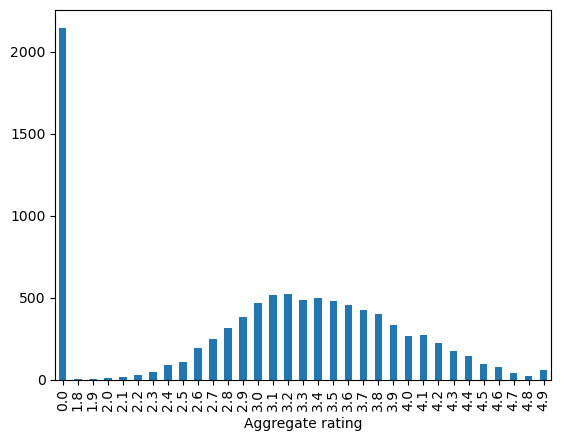

In [5]:
df['Aggregate rating'].value_counts().sort_index().plot(kind='bar')

In [6]:
common_rating=df['Aggregate rating'].value_counts().head(1)
common_rating

Aggregate rating
0.0    2148
Name: count, dtype: int64

In [8]:
print('Most common Rating is',common_rating)

Most common Rating is Aggregate rating
0.0    2148
Name: count, dtype: int64


### Calculate the average number of votes received by restaurants.

In [9]:
print(df['Votes'].mean())

156.909747670401


## Task2-Cuisine Combination

### Identify the most common combinations of cuisines in the dataset

In [10]:
cuisine_combination=df[df['Cuisines'].str.contains(',',na=False)]
cuisine_combination['Cuisines'].value_counts().head(10)

Cuisines
North Indian, Chinese             511
North Indian, Mughlai             334
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Pizza, Fast Food                  131
Chinese, Fast Food                118
Mithai, Street Food               116
Bakery, Fast Food                 108
Chinese, North Indian             105
Ice Cream, Desserts                83
Name: count, dtype: int64

<Axes: xlabel='Cuisines'>

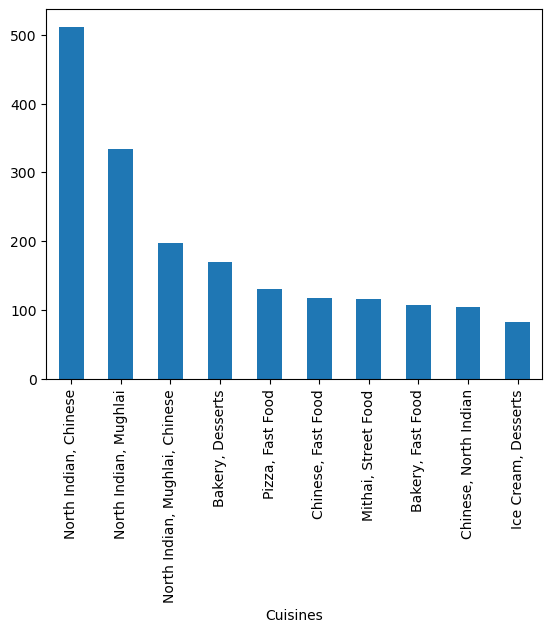

In [12]:
cuisine_combination['Cuisines'].value_counts().head(10).plot(kind='bar')

### Determine if certain cuisine combinations tend to have higher ratings.

In [13]:
cuisine_combination.groupby('Cuisines')['Aggregate rating'].mean().sort_values(ascending=False).head(10)

Cuisines
Italian, Deli               4.9
Continental, Indian         4.9
Hawaiian, Seafood           4.9
American, Burger, Grill     4.9
American, Coffee and Tea    4.9
European, Contemporary      4.9
Sunda, Indonesian           4.9
European, German            4.9
BBQ, Breakfast, Southern    4.9
Mughlai, Lucknowi           4.9
Name: Aggregate rating, dtype: float64

<Axes: xlabel='Cuisines'>

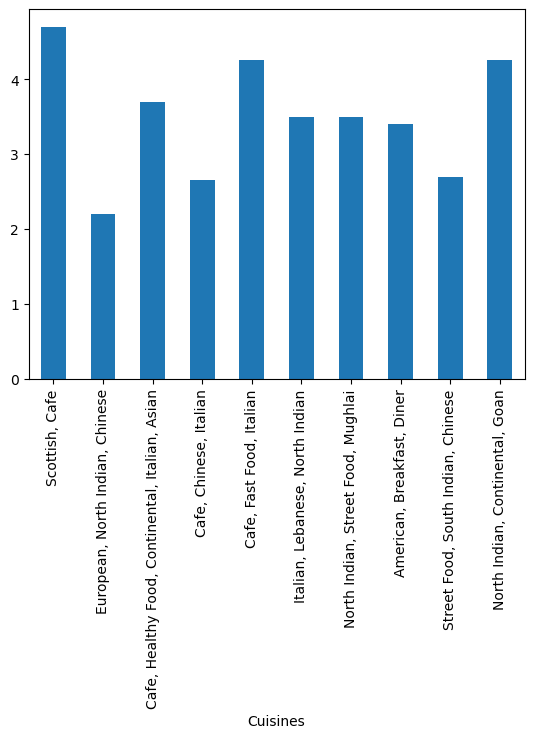

In [17]:
cuisine_combination.groupby('Cuisines')['Aggregate rating'].mean().sort_values(ascending=False).sample(10).plot(kind='bar')

## Task3-Geographic Analysis

### Plot the locations of restaurants on a map using longitude and latitude coordinates


In [14]:
pip install folium

Note: you may need to restart the kernel to use updated packages.


In [15]:
import folium

In [16]:
m = folium.Map(
    location=[df['Latitude'].mean(), df['Longitude'].mean()],
    zoom_start=5
)

In [17]:
for _, row in df.head(100).iterrows():
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=row['Restaurant Name']
    ).add_to(m)

In [18]:
m

### Identify any patterns or clusters of restaurants in specific areas

Text(0, 0.5, 'Latitude')

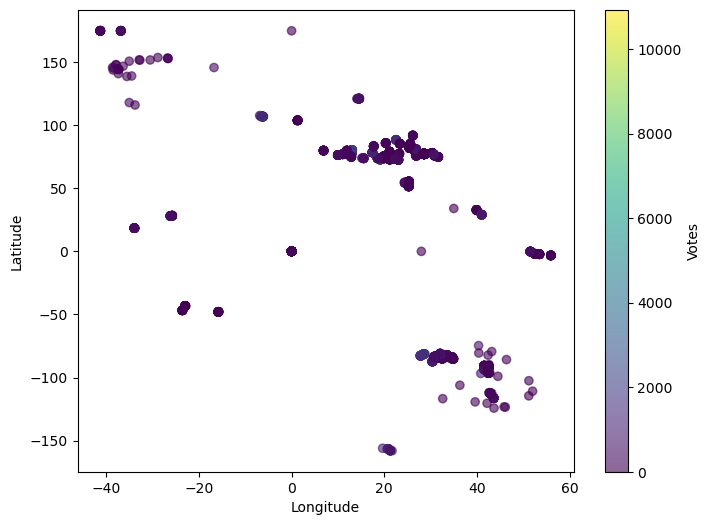

In [19]:
plt.figure(figsize=(8,6))
plt.scatter(df['Latitude'],df['Longitude'],c=df['Votes'],alpha=0.6)
plt.colorbar(label='Votes')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

## Task4-Restaurant Chains

### Identify if there are any restaurant chains present in the dataset

In [20]:
mask=df['Restaurant Name'].value_counts()
mask[mask>1].head(10)

Restaurant Name
Cafe Coffee Day     83
Domino's Pizza      79
Subway              63
Green Chick Chop    51
McDonald's          48
Keventers           34
Pizza Hut           30
Giani               29
Baskin Robbins      28
Barbeque Nation     26
Name: count, dtype: int64

### Analyze the ratings and popularity of different restaurant chains

In [24]:
mask=df.groupby('Restaurant Name').agg(Average_Rating=('Aggregate rating','mean'),Average_votes=('Votes','mean'),Number_of_outlets=('Restaurant Name','count'))

In [25]:
mask=mask[mask['Number_of_outlets']>1]

In [26]:
mask.sort_values(by='Average_Rating',ascending=False).head(10)

,Average_Rating,Average_votes,Number_of_outlets
Restaurant Name,,,
Talaga Sampireun,4.900,1838.0,3
Silantro Fil-Mex,4.850,682.0,2
AB's Absolute Barbecues,4.850,1575.5,2
AB's - Absolute Barbecues,4.825,3350.0,4
Naturals Ice Cream,4.800,1547.0,2
Gymkhana,4.700,164.0,2
The Cheesecake Factory,4.650,1505.0,2
Dishoom,4.600,634.5,2
Garota de Ipanema,4.600,29.5,2
